# BÀI TẬP VỀ NHÀ — BUỔI 2: XÁC SUẤT THỐNG KÊ CHO AI



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## PHẦN 1 — THỐNG KÊ MÔ TẢ & ĐẶC TRƯNG




In [2]:
# 1. Đọc dữ liệu và hiển thị 5 dòng đầu tiên
df = sns.load_dataset("iris")
print(" 5 dòng đầu tiên của dữ liệu Iris ")
display(df.head())

# Số dòng, số cột, kiểu dữ liệu của từng cột 
print(f"\nKích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nKiểu dữ liệu của từng cột:")
print(df.dtypes)


 5 dòng đầu tiên của dữ liệu Iris 


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Kích thước tập dữ liệu: 150 dòng, 5 cột

Kiểu dữ liệu của từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [3]:
# 2. Tính các đặc trưng thống kê mô tả cho từng biến số
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
stats = {}
for col in features:
    col_data = df[col]
    mean_val = col_data.mean()
    median_val = col_data.median()
    
    modes = col_data.mode()
    mode_val = "; ".join(modes.astype(str))
    
    var_val = col_data.var()
    std_val = col_data.std()
    min_val = col_data.min()
    max_val = col_data.max()
    q1_val = col_data.quantile(0.25)
    q3_val = col_data.quantile(0.75)
    iqr_val = q3_val - q1_val
    
    stats[col] = {
        'mean': mean_val,
        'median': median_val,
        'mode': mode_val,
        'var': var_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'Q1': q1_val,
        'Q3': q3_val,
        'IQR': iqr_val
    }

stats_df = pd.DataFrame(stats)
print("--- Bảng các chỉ số thống kê mô tả ---")
display(stats_df)


--- Bảng các chỉ số thống kê mô tả ---


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.057333,3.758,1.199333
median,5.8,3.0,4.35,1.3
mode,5.0,3.0,1.4; 1.5,0.2
var,0.685694,0.189979,3.116278,0.581006
std,0.828066,0.435866,1.765298,0.762238
min,4.3,2.0,1.0,0.1
max,7.9,4.4,6.9,2.5
Q1,5.1,2.8,1.6,0.3
Q3,6.4,3.3,5.1,1.8
IQR,1.3,0.5,3.5,1.5


In [4]:
# 3. Gom nhóm theo loài (species) tính mean và std
grouped_stats = df.groupby('species')[features].agg(['mean', 'std'])
print(" Giá trị trung bình và độ lệch chuẩn theo từng loài ")
display(grouped_stats)


 Giá trị trung bình và độ lệch chuẩn theo từng loài 


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

### Nhận xét Phần 1:
1. **Cấu trúc dữ liệu**: Tập dữ liệu Iris chứa **150 quan mẫu** và **5 thuộc tính**, trong đó có 4 biến số thực đo lường kích thước đài hoa và cánh hoa, và 1 biến phân loại đại diện cho loài hoa (`species`).
2. **Loài hoa khác biệt rõ rệt nhất**: Loài **setosa** tách biệt hoàn toàn so với 2 loài còn lại.
   - Kích thước cánh hoa của setosa cực kỳ nhỏ: trung bình chiều dài cánh hoa (`petal_length`) chỉ là **1.462 cm** và chiều rộng cánh hoa (`petal_width`) chỉ là **0.246 cm**.
   - Độ lệch chuẩn (`std`) của cánh hoa loài setosa cũng rất thấp (lần lượt là **0.174 cm** và **0.105 cm**), cho thấy kích thước của các cá thể setosa rất đồng đều và phân cụm cực kỳ tập trung so với loài `versicolor` và `virginica`.


## PHẦN 2 — PHÂN PHỐI XÁC SUẤT



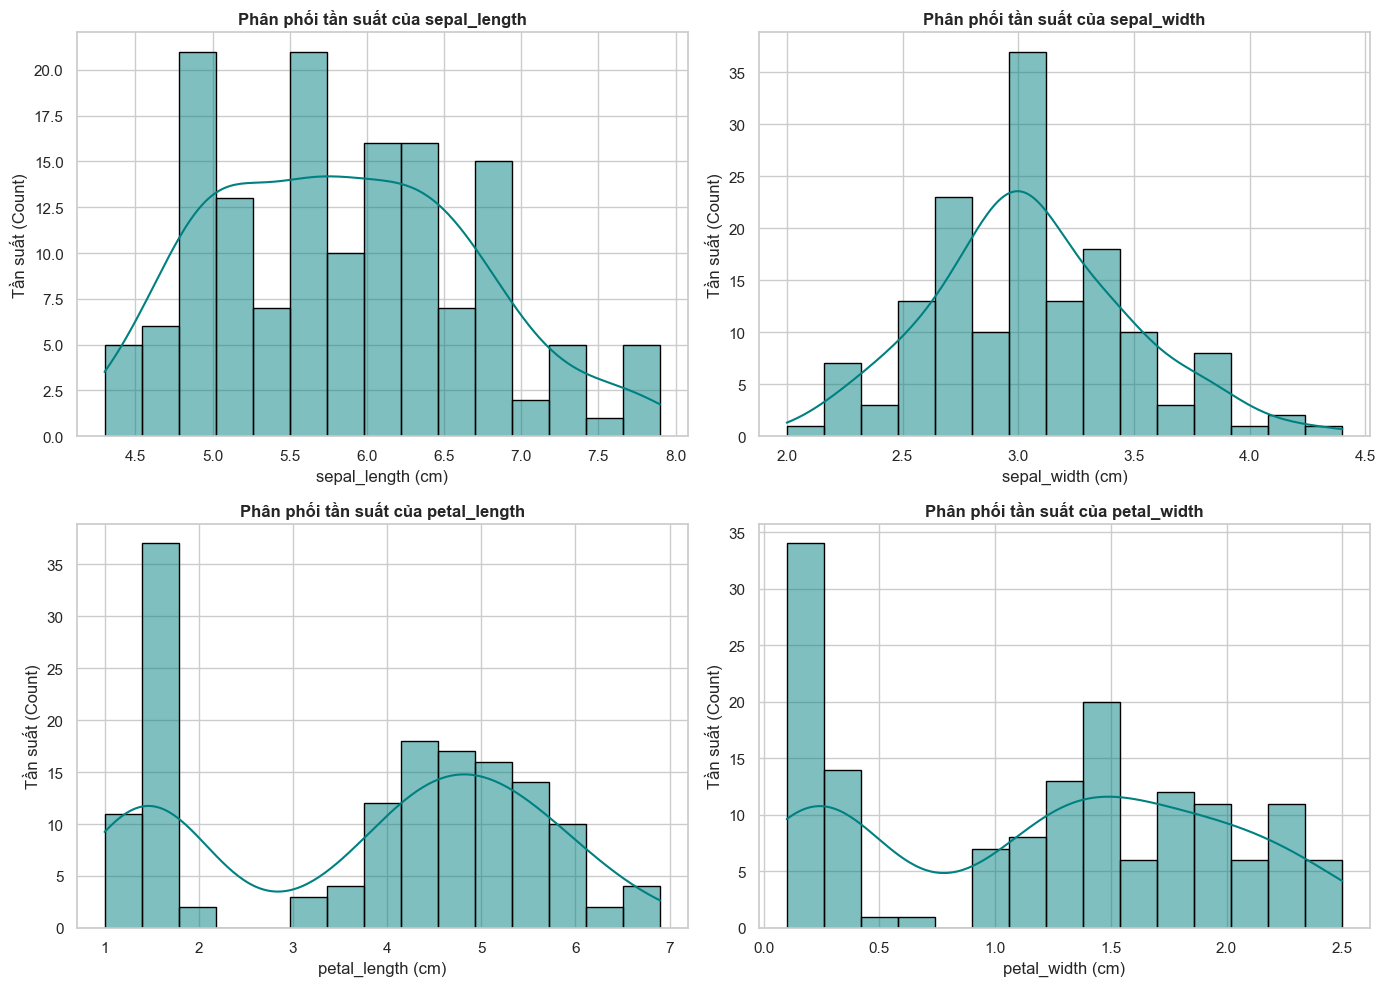

In [5]:
# 1. Vẽ histogram + KDE cho từng biến số
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='teal', edgecolor='black', bins=15)
    axes[idx].set_title(f"Phân phối tần suất của {col}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col + " (cm)")
    axes[idx].set_ylabel("Tần suất (Count)")

plt.tight_layout()
plt.show()


1. **Đánh giá hình dạng phân phối (Histogram + KDE)**:
   - `sepal_length`: phân phối tương đối phẳng, trải rộng và không rõ một đỉnh duy nhất, do đó nó không thực sự tuân theo phân phối chuẩn.
   - `sepal_width`: Phân phối có dạng quả chuông cân đối nhất, tập trung cao ở khoảng 3.0 cm, rất gần với phân phối chuẩn.
   - `petal_length` và `petal_width`: Phân phối có **hai đỉnh rõ rệt**. Đỉnh thứ nhất rất dốc ở các giá trị nhỏ (đại diện cho loài setosa), đỉnh thứ hai dẹt hơn và trải dài ở các giá trị lớn hơn (đại diện cho loài versicolor và virginica).

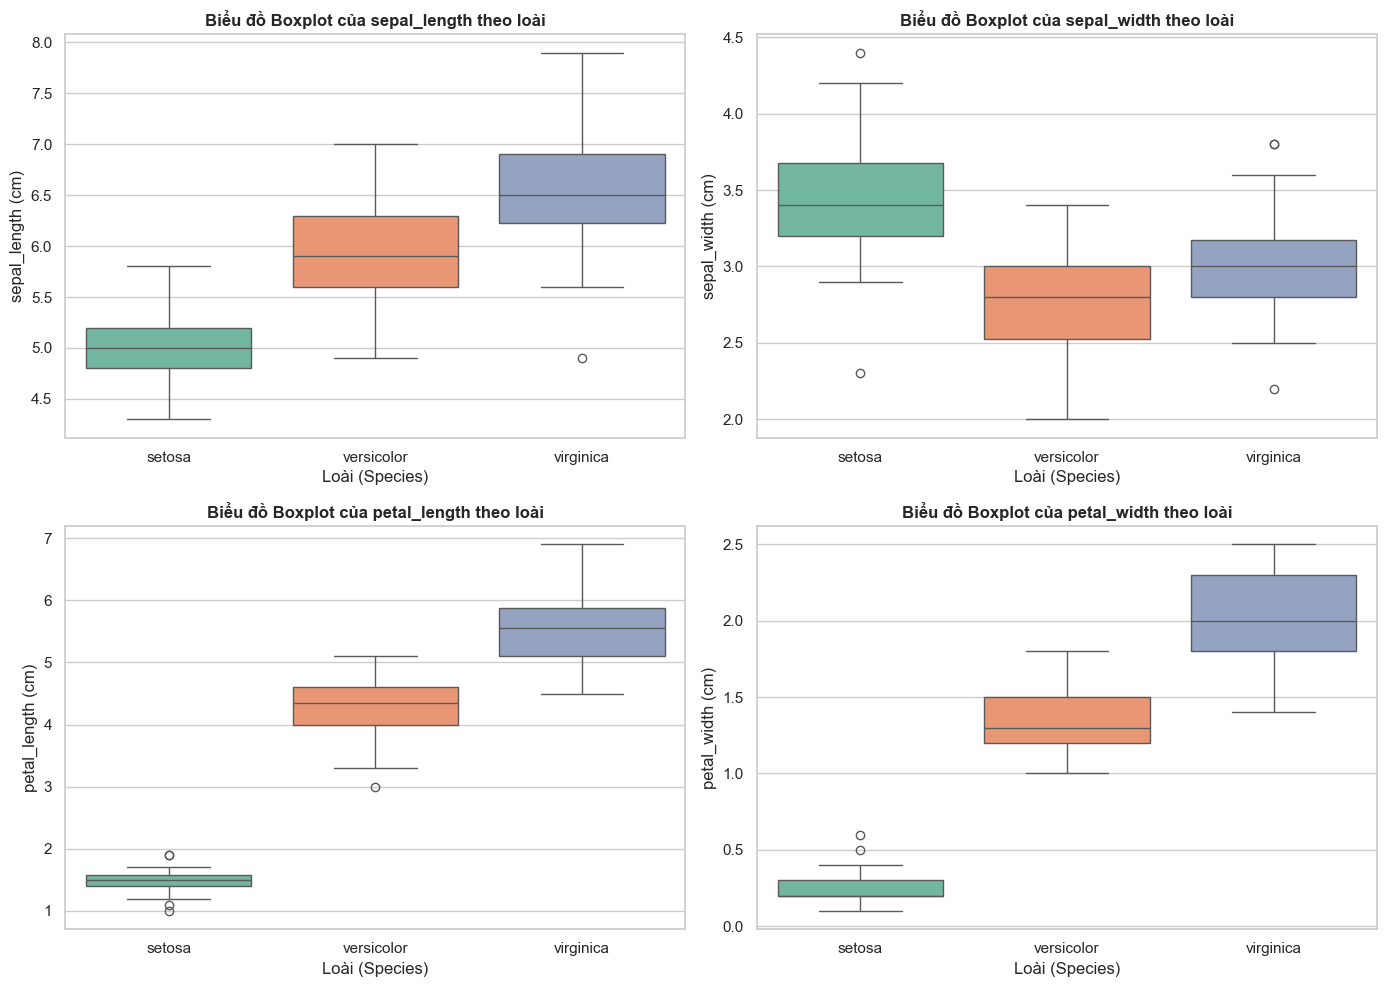

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Vẽ boxplot từng biến theo nhóm (species)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.boxplot(x='species', y=col, data=df, ax=axes[idx], hue='species', palette='Set2', legend=False)
    
    axes[idx].set_title(f"Biểu đồ Boxplot của {col} theo loài", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Loài (Species)")
    axes[idx].set_ylabel(col + " (cm)")

plt.tight_layout()
plt.show()

2. **So sánh qua Boxplot**:

#### **1. Sepal**

* **`sepal_length`:** Có sự phân cấp kích thước tăng dần rõ rệt theo thứ tự: $\text{setosa} < \text{versicolor} < \text{virginica}$. Trong đó, `setosa` ngắn nhất (trung vị $\approx 5.0$ cm), `virginica` dài nhất (trung vị $\approx 6.5$ cm). Xuất hiện một điểm ngoại lệ thấp (outlier) ở loài `virginica`.
* **`sepal_width`:** Phân phối có xu hướng ngược lại. `setosa` có đài hoa to bản nhất (trung vị $\approx 3.4$ cm), trong khi `versicolor` và `virginica` hẹp hơn và có dải dữ liệu khá tương đồng nhau. Biến này ghi nhận nhiều giá trị ngoại lệ nhất ở cả 3 loài (xuất hiện ở cả hai đầu râu).

#### **2. Petal**

* **`petal_length`:** Đặc trưng này giúp phân tách hoàn toàn loài `setosa` ra khỏi hai loài còn lại. `setosa` có cánh hoa cực kỳ ngắn và đồng đều (hộp bẹt, biến động ít). Hai loài `versicolor` và `virginica` có cánh hoa dài hơn rõ rệt nhưng dải phân phối có sự giao thoa nhẹ ở khoảng $4.5 - 5.0$ cm.
* **`petal_width`:** Tiếp tục thể hiện sự phân bậc rõ ràng giữa 3 nhóm. Cánh hoa `setosa` siêu mảnh ($\approx 0.1 - 0.4$ cm), `versicolor` ở mức trung bình ($\approx 1.0 - 1.5$ cm) và `virginica` có bề ngang dày nhất ($\approx 1.5 - 2.5$ cm).

---



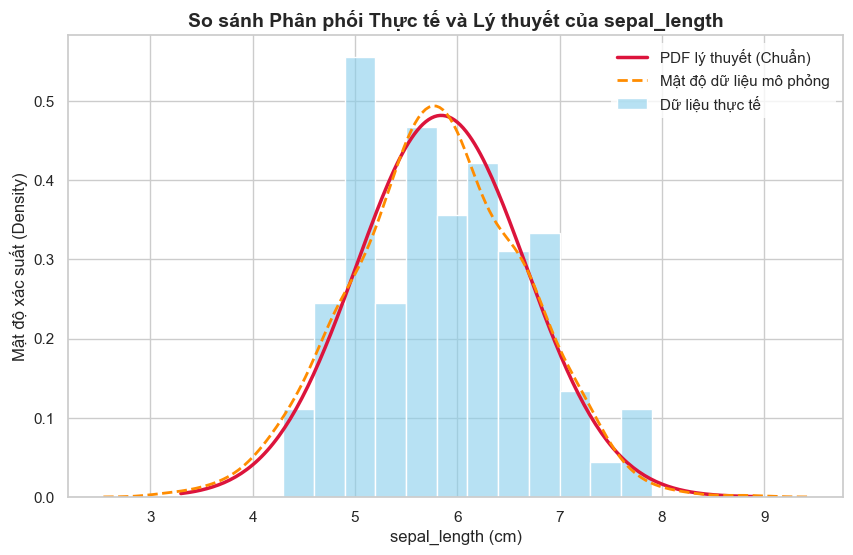

In [7]:
# 3. Mô phỏng phân phối chuẩn cho biến sepal_length
target_col = 'sepal_length'
mu = df[target_col].mean()
sigma = df[target_col].std()

# Sinh mẫu ngẫu nhiên từ phân phối chuẩn có cùng mean và std
np.random.seed(123)
simulated_data = np.random.normal(mu, sigma, size=1000)

# Vẽ biểu đồ so sánh phân phối thực tế vs PDF lý thuyết và dữ liệu mô phỏng
plt.figure(figsize=(10, 6))

# Histogram thực tế (tỉ lệ mật độ)
sns.histplot(df[target_col], stat="density", label="Dữ liệu thực tế", color="skyblue", alpha=0.6, edgecolor='white', bins=12)

# Đường PDF lý thuyết
x_vals = np.linspace(df[target_col].min() - 1, df[target_col].max() + 1, 200)
pdf_vals = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- (x_vals - mu)**2 / (2 * sigma**2))
plt.plot(x_vals, pdf_vals, color='crimson', linewidth=2.5, label="PDF lý thuyết (Chuẩn)")

# Phân phối mật độ của dữ liệu mô phỏng
sns.kdeplot(simulated_data, color='darkorange', linestyle='--', linewidth=2, label="Mật độ dữ liệu mô phỏng")

plt.title(f"So sánh Phân phối Thực tế và Lý thuyết của {target_col}", fontsize=14, fontweight='bold')
plt.xlabel(f"{target_col} (cm)")
plt.ylabel("Mật độ xác suất (Density)")
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.show()




### **Nhận xét mức độ khớp giữa Phân phối Thực tế và Lý thuyết của `sepal_length`**

Dựa vào đồ thị so sánh giữa dữ liệu thực tế, đường cong PDF lý thuyết và dữ liệu mô phỏng, ta có các đánh giá sau:

* **Mức độ tương đồng tổng thể:** Đường cong mật độ của dữ liệu mô phỏng ngẫu nhiên (đường nét đứt màu cam) bám rất sát với đường PDF lý thuyết (đường liền nét màu đỏ). Điều này chứng minh quá trình giả lập mẫu tuân thủ chính xác quy luật phân phối chuẩn.
* **Mức độ khớp của dữ liệu thực tế:** * Biểu đồ histogram của dữ liệu thực tế (các cột màu xanh) nhìn chung phân bố khá đều và đối xứng xung quanh giá trị trung bình ($\mu \approx 5.84$ cm), ôm theo form dáng của đường cong chuẩn lý thuyết.
* Tuy nhiên, dữ liệu thực tế có xu hướng **đa đỉnh nhẹ** (nhô cao hẳn ở khoảng $5.0$ cm và $5.8$ cm) và bị "hụt" một khoảng dữ liệu ở mức $5.2 - 5.4$ cm so với kỳ vọng lý thuyết.



Biến `sepal_length` có phân phối thực tế **khớp ở mức độ trung bình khá** so với phân phối chuẩn lý thuyết. Dù không hoàn hảo tuyệt đối do sự pha trộn đặc trưng kích thước giữa 3 loài hoa khác nhau, nhưng hình dáng tổng thể của nó vẫn đủ điều kiện để xấp xỉ bằng một phân phối chuẩn trong các bài toán thống kê cơ bản.

### Nhận xét Phần 2:


Qua quá trình phân tích thống kê mô tả, trực quan hóa hình dạng phân phối và mô phỏng lý thuyết trên bộ dữ liệu, nghiên cứu rút ra các kết luận trọng tâm sau:

1. **Giá trị phân loại của đặc trưng kích thước cánh hoa:** Kích thước cánh hoa (bao gồm `petal_length` và `petal_width`) sở hữu biến động nội nhóm nhỏ nhưng sự khác biệt giữa các nhóm rất lớn, tạo nên cấu trúc phân phối hai đỉnh biệt lập. Đây là hai thuộc tính cốt lõi có giá trị thông tin cao nhất, giúp phân tách hoàn toàn loài `setosa` và là cơ sở quan trọng cho các mô hình phân lớp dữ liệu.

2. **Sự chồng lấn hình thái giữa các loài hoa còn lại:** Trái ngược với vị trí biệt lập của loài `setosa`, hai quần thể `versicolor` và `virginica` luôn tồn tại các vùng chồng lấn dữ liệu trên cả bốn chiều đặc trưng bao gồm `sepal_length`, `sepal_width`, `petal_length` và `petal_width`. 

3. **Bản chất của giả định phân phối chuẩn trong thực tế:** Thử nghiệm mô phỏng trên biến `sepal_length` chỉ ra rằng biến số này chỉ đạt mức độ tương thích trung bình khá so với phân phối chuẩn lý thuyết. Sự sai lệch cục bộ (như hiện tượng đa đỉnh, khuyết thiếu tần suất) là hệ quả của việc gộp chung các quần thể con mang đặc tính sinh học riêng biệt, nhắc nhở việc cần phân rã dữ liệu theo từng phân lớp trong biến `species` khi thực hiện các kiểm định thống kê chuyên sâu.


## PHẦN 3 — PHÂN TÍCH ĐA BIẾN & TƯƠNG QUAN

Trong phần này, chúng ta sẽ thực hiện:
1. Tính toán ma trận hiệp phương sai (Covariance Matrix) và ma trận hệ số tương quan (Correlation Matrix) giữa các biến.
2. Vẽ biểu đồ nhiệt (Heatmap) thể hiện ma trận tương quan và kiểm tra hiện tượng đa cộng tuyến.
3. Vẽ biểu đồ phân tán cặp thuộc tính (Pairplot) phân nhóm theo loài (`species`) để nhận xét quan hệ giữa các biến số.


In [8]:
# 1. Tính toán ma trận hiệp phương sai và tương quan
cov_matrix = df[features].cov()
corr_matrix = df[features].corr()

print("Ma trận hiệp phương sai (Covariance Matrix)")
display(cov_matrix)
print("\nMa trận tương quan Pearson (Correlation Matrix)")
display(corr_matrix)


Ma trận hiệp phương sai (Covariance Matrix)


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



Ma trận tương quan Pearson (Correlation Matrix)


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


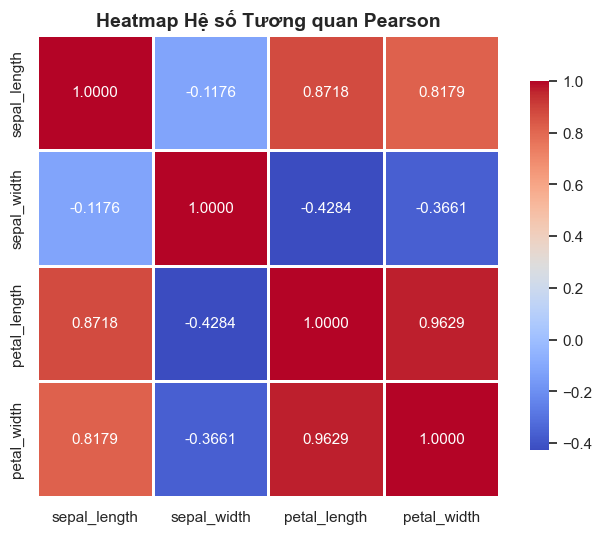

In [9]:
# 2. Vẽ biểu đồ nhiệt Heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", square=True, linewidths=0.8, cbar_kws={'shrink': 0.8})
plt.title("Heatmap Hệ số Tương quan Pearson", fontsize=14, fontweight='bold')
plt.show()


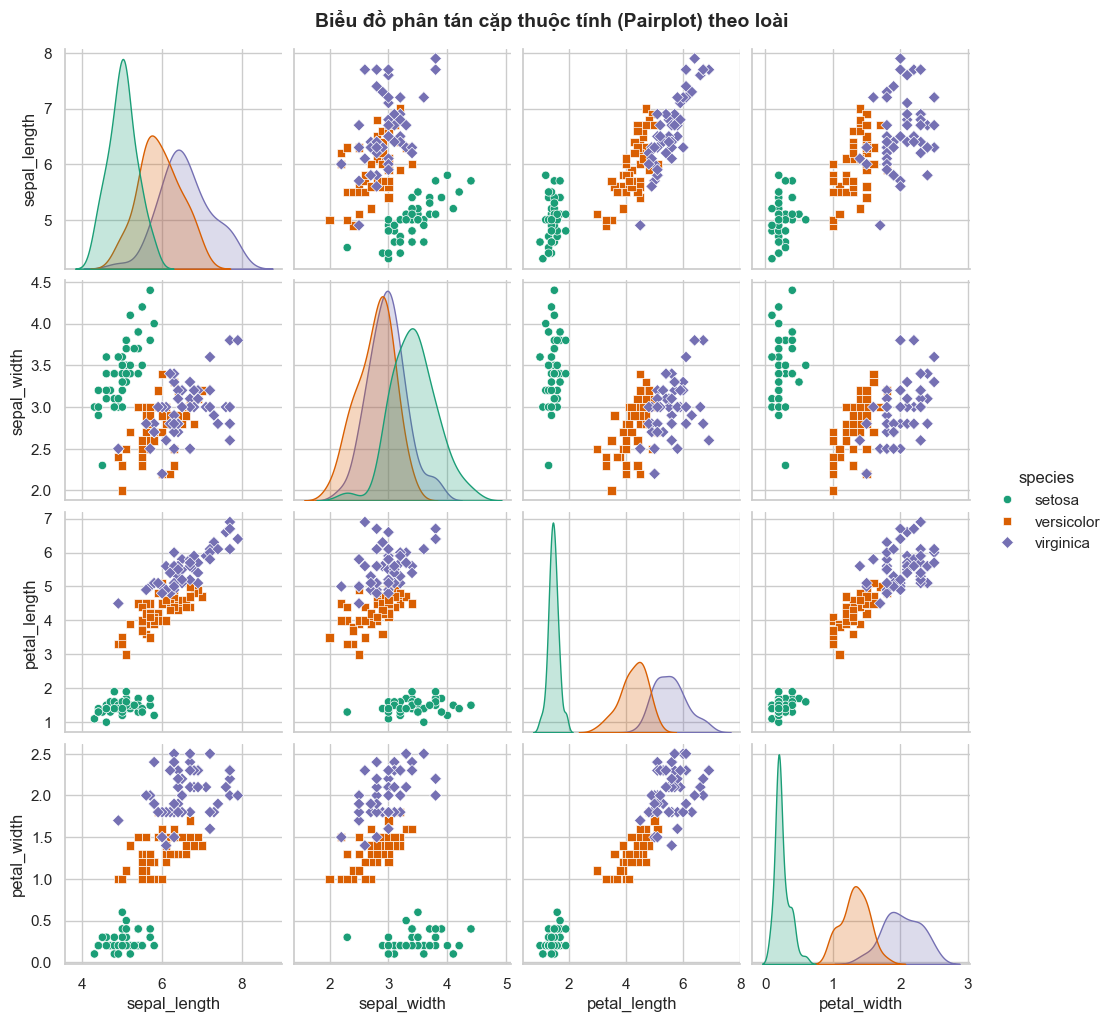

In [10]:
# 3. Vẽ Pairplot phân tách theo loài
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='Dark2')
plt.suptitle("Biểu đồ phân tán cặp thuộc tính (Pairplot) theo loài", y=1.02, fontsize=14, fontweight='bold')
plt.show()


### Nhận xét Phần 3:
1. **Cặp biến tương quan mạnh nhất**: Cặp **`petal_length` và `petal_width`** có hệ số tương quan dương cực kỳ mạnh mẽ là **0.9629** (xấp xỉ $96.3\%$). Điều này cho thấy khi cánh hoa dài hơn thì bề ngang của nó cũng có xu hướng lớn hơn tương ứng.
2. **Hiện tượng đa cộng tuyến (Multicollinearity)**:
   - Có dấu hiệu đa cộng tuyến rõ rệt giữa các biến liên quan đến cánh hoa (`petal_length`, `petal_width`) và đài hoa (`sepal_length`).
3. **Quan hệ giữa các biến qua Pairplot**:
   - Các thuộc tính cánh hoa (`petal_length`, `petal_width`) giúp phân loại hoàn hảo loài setosa khỏi hai loài còn lại.
   - Giữa loài versicolor và virginica có một số vùng phân bố chồng lấn nhẹ, nhưng khi quan sát đồ thị hai chiều của `petal_length` kết hợp `petal_width`, hai loài này vẫn phân cụm tách biệt rất rõ ràng.


## PHẦN 4 — XÁC SUẤT & ĐỊNH LÝ BAYES

### Bài toán chẩn đoán y khoa:
- Tỉ lệ mắc bệnh trong dân số: $P(B) = 0.01$ (tương đương 1%).
- Độ nhạy của xét nghiệm (True Positive): $P(+ \mid B) = 0.99$.
- Tỉ lệ dương tính giả (False Positive): $P(+ \mid \neg B) = 0.05$.

Trong phần này, chúng ta sẽ:
1. Viết code tính toán xác suất hậu nghiệm một người thực sự mắc bệnh khi có kết quả dương tính: $P(B \mid +)$.
2. Khảo sát đồ thị biểu diễn sự thay đổi của $P(B \mid +)$ khi tỉ lệ mắc bệnh nền $P(B)$ thay đổi từ 0.001 (0.1%) đến 0.2 (20%). Giải thích tại sao kết quả lại gây cảm giác phản trực giác khi bệnh hiếm.
3. **[Bonus]** Thiết kế và lập trình một bộ lọc thư rác (Spam Filter) đơn giản ứng dụng mô hình Naive Bayes từ đầu trong Python.


In [11]:
# 1. Viết code tính xác suất hậu nghiệm P(B | +)
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_NB = 0.05

# P(not B)
P_NB = 1.0 - P_B

# Xác suất kết quả xét nghiệm dương tính P(+)
P_pos = P_pos_given_B * P_B + P_pos_given_NB * P_NB

# Định lý Bayes tính P(B | +)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất thực sự mắc bệnh khi xét nghiệm dương tính P(B|+) = {P_B_given_pos:.4f} ({P_B_given_pos*100:.2f}%)")


Xác suất thực sự mắc bệnh khi xét nghiệm dương tính P(B|+) = 0.1667 (16.67%)


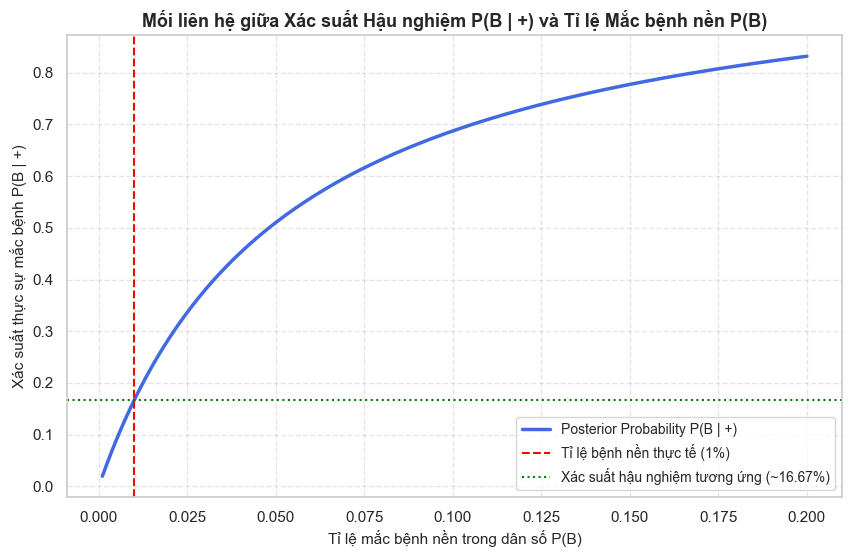

In [12]:
# 2. Vẽ đồ thị khảo sát sự thay đổi của P(B | +) khi P(B) thay đổi từ 0.001 đến 0.2
P_B_range = np.linspace(0.001, 0.2, 300)
P_pos_range = P_pos_given_B * P_B_range + P_pos_given_NB * (1.0 - P_B_range)
P_B_given_pos_range = (P_pos_given_B * P_B_range) / P_pos_range

plt.figure(figsize=(10, 6))
plt.plot(P_B_range, P_B_given_pos_range, color='royalblue', linewidth=2.5, label="Posterior Probability P(B | +)")
plt.axvline(x=0.01, color='red', linestyle='--', label='Tỉ lệ bệnh nền thực tế (1%)')
plt.axhline(y=0.1667, color='green', linestyle=':', label='Xác suất hậu nghiệm tương ứng (~16.67%)')

plt.title("Mối liên hệ giữa Xác suất Hậu nghiệm P(B | +) và Tỉ lệ Mắc bệnh nền P(B)", fontsize=13, fontweight='bold')
plt.xlabel("Tỉ lệ mắc bệnh nền trong dân số P(B)", fontsize=11)
plt.ylabel("Xác suất thực sự mắc bệnh P(B | +)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.show()




### **Giải thích hiện tượng "Phản trực giác" (Base Rate Fallacy / Nghịch lý dương tính giả)**

Hiện tượng một xét nghiệm có độ chính xác cao nhưng lại cho xác suất mắc bệnh thực tế thấp khi nhận kết quả dương tính là do **Sai lầm tỷ lệ nền (Base Rate Fallacy)**.

#### **1. Nguyên nhân cốt lõi**

Hiện tượng này xảy ra khi **tỷ lệ bệnh nền trong cộng đồng quá thấp** so với số lượng người khỏe mạnh. Quy mô khổng lồ của nhóm người khỏe mạnh làm cho số ca **dương tính giả** (dù tỷ lệ lỗi rất nhỏ) bị khuếch đại lên gấp nhiều lần, áp đảo hoàn toàn số ca **dương tính thật**.

#### **2. Minh chứng thực nghiệm (Quy mô dân số: 100,000 người, Tỷ lệ bệnh nền: 1%)**

* **Nhóm mắc bệnh thực tế ($1\%$):** $1,000$ người.
* Xét nghiệm đúng $99\%$ (Độ nhạy) $\to$ **$990$ người dương tính thật**.


* **Nhóm khỏe mạnh thực tế ($99\%$):** $99,000$ người.
* Xét nghiệm sai $5\%$ (Tỷ lệ dương tính giả) $\to$ **$4,950$ người dương tính giả**.


* **Xác suất hậu nghiệm:**
* Tổng số ca có kết quả dương tính ($+$): $990 + 4,950 = 5,940$ người.
* Tỷ lệ một người nhận kết quả dương tính thực sự có bệnh ($b$):

$$P(b \mid +) = \frac{990}{5,940} \approx 16.67\%$$





> **Kết luận:** Vì nhóm dương tính giả lớn gấp **5 lần** nhóm dương tính thật, xác suất thực sự mắc bệnh bị kéo giảm sâu. Khi bệnh càng hiếm (tỷ lệ nền tiến về $0$), xác suất $P(b \mid +)$ càng giảm mạnh, giải thích vì sao đường đồ thị dốc đứng ở giai đoạn đầu.

### 3. [Bonus] Xây dựng bộ lọc thư rác (Spam Filter) Naive Bayes từ đầu

Mô hình sử dụng thuật toán **Multinomial Naive Bayes** với kỹ thuật làm trơn Laplace ($\alpha = 1$) để phân loại văn bản.


In [13]:
class SimpleNaiveBayesSpamFilter:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Tham số làm trơn Laplace
        self.vocab = set()  # Lưu trữ các từ duy nhất trong tập huấn luyện
        self.word_counts_spam = collections.Counter()
        self.word_counts_ham = collections.Counter()
        self.total_words_spam = 0
        self.total_words_ham = 0
        self.p_spam = 0.0
        self.p_ham = 0.0
        
    def tokenize(self, text):
        # Chuẩn hóa về chữ thường và trích xuất các từ đơn giản
        return re.findall(r'\b\w+\b', text.lower())
        
    def fit(self, data):
        num_spam = sum(1 for text, label in data if label == 'spam')
        num_ham = sum(1 for text, label in data if label == 'ham')
        total = num_spam + num_ham
        self.p_spam = num_spam / total
        self.p_ham = num_ham / total
        
        for text, label in data:
            words = self.tokenize(text)
            for w in words:
                self.vocab.add(w)
                if label == 'spam':
                    self.word_counts_spam[w] += 1
                    self.total_words_spam += 1
                else:
                    self.word_counts_ham[w] += 1
                    self.total_words_ham += 1
                    
    def predict_probability(self, text):
        words = self.tokenize(text)
        
        # Sử dụng log để tránh tràn số dưới (numerical underflow)
        log_p_spam_given_words = np.log(self.p_spam)
        log_p_ham_given_words = np.log(self.p_ham)
        vocab_size = len(self.vocab)
        
        for w in words:
            if w in self.vocab:
                # Tính xác suất có điều kiện kết hợp Laplace Smoothing
                p_w_spam = (self.word_counts_spam[w] + self.alpha) / (self.total_words_spam + self.alpha * vocab_size)
                log_p_spam_given_words += np.log(p_w_spam)
                
                p_w_ham = (self.word_counts_ham[w] + self.alpha) / (self.total_words_ham + self.alpha * vocab_size)
                log_p_ham_given_words += np.log(p_w_ham)
        
        # Áp dụng công thức Bayes log-sum-exp ổn định để tính xác suất hậu nghiệm
        diff = log_p_ham_given_words - log_p_spam_given_words
        p_spam_posterior = 1.0 / (1.0 + np.exp(diff))
        p_ham_posterior = 1.0 - p_spam_posterior
        
        return p_spam_posterior, p_ham_posterior

train_data = [
    ("buy cheap replica watches now free shipping", "spam"),
    ("win free cash prize click here to claim", "spam"),
    ("urgent offer get free coins and money now", "spam"),
    ("official notice of account suspension click here", "spam"),
    ("please review the project schedule for the meeting", "ham"),
    ("are you available for a phone call tomorrow", "ham"),
    ("here is the draft report for your review", "ham"),
    ("we need to discuss the budget and timeline", "ham")
]

# Huấn luyện mô hình
spam_filter = SimpleNaiveBayesSpamFilter(alpha=1.0)
spam_filter.fit(train_data)

# Các ví dụ kiểm thử
test_emails = [
    "free money click now",
    "please send the project report tomorrow",
    "urgent meeting to discuss free cash"
]

print("--- Kết quả thử nghiệm bộ lọc Spam Naive Bayes ---")
for email in test_emails:
    p_spam, p_ham = spam_filter.predict_probability(email)
    prediction = "SPAM (Thư rác)" if p_spam > 0.5 else "HAM (Thư thường)"
    print(f"\nEmail: \"{email}\"")
    print(f"  Xác suất là Spam: {p_spam*100:.2f}%")
    print(f"  Xác suất là Ham:  {p_ham*100:.2f}%")
    print(f"  -> Dự đoán:       {prediction}")


--- Kết quả thử nghiệm bộ lọc Spam Naive Bayes ---

Email: "free money click now"
  Xác suất là Spam: 98.76%
  Xác suất là Ham:  1.24%
  -> Dự đoán:       SPAM (Thư rác)

Email: "please send the project report tomorrow"
  Xác suất là Spam: 1.40%
  Xác suất là Ham:  98.60%
  -> Dự đoán:       HAM (Thư thường)

Email: "urgent meeting to discuss free cash"
  Xác suất là Spam: 82.32%
  Xác suất là Ham:  17.68%
  -> Dự đoán:       SPAM (Thư rác)
